# Football World Cup KPIs
Data sourced from `foot_etl.duckdb` — dbt star schema: `fct_match`, `dim_team`, `dim_stadium`, `dim_city`, `dim_edition`.

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 120

DB = "../foot_etl.duckdb"
con = duckdb.connect(DB, read_only=True)
print("Connected to", DB)

Connected to ../foot_etl.duckdb


In [2]:
# ── Load unified match view (all editions) ───────────────────────────────────
matches = con.execute("""
    SELECT
        m.id_match,
        m.date,
        m.round,
        m.home_result,
        m.away_result,
        m.result,
        ht.team_name  AS home_team,
        awt.team_name AS away_team,
        s.stadium_name,
        c.city_name,
        e.year        AS edition_year,
        e.edition_name
    FROM fct_match m
    JOIN dim_team    ht  ON ht.id_team   = m.id_home_team
    JOIN dim_team    awt ON awt.id_team  = m.id_away_team
    JOIN dim_stadium s   ON s.id_stadium = m.id_stadium
    JOIN dim_city    c   ON c.id_city    = s.id_city
    JOIN dim_edition e   ON e.id_edition = m.id_edition
    ORDER BY m.id_match
""").df()

matches["total_goals"] = matches["home_result"] + matches["away_result"]
print(f"Total matches: {len(matches)} | Editions: {matches['edition_year'].nunique()}")
print(matches.groupby("edition_year").size().to_string())

Total matches: 964 | Editions: 22
edition_year
1930    18
1934    17
1938    18
1950    22
1954    26
1958    35
1962    32
1966    32
1970    32
1974    38
1978    38
1982    52
1986    52
1990    52
1994    52
1998    64
2002    64
2006    64
2010    64
2014    64
2018    64
2022    64


## KPI 1 — Average goals per match by edition (1930–2022)

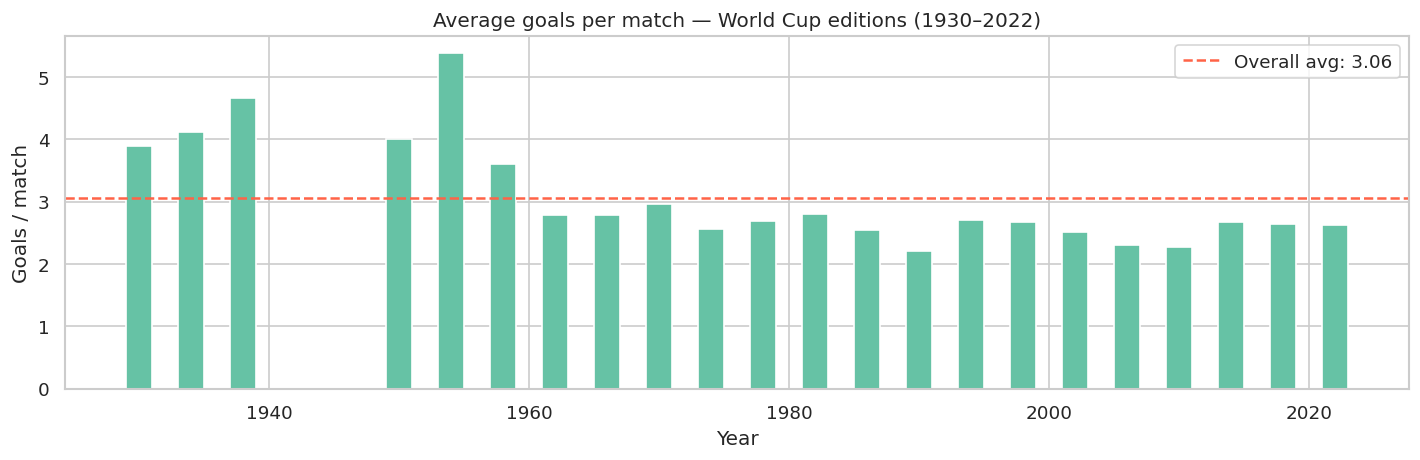

              goals  n_matches  goals_per_match
edition_year                                   
1930             70         18         3.888889
1934             70         17         4.117647
1938             84         18         4.666667
1950             88         22         4.000000
1954            140         26         5.384615
1958            126         35         3.600000
1962             89         32         2.781250
1966             89         32         2.781250
1970             95         32         2.968750
1974             97         38         2.552632
1978            102         38         2.684211
1982            146         52         2.807692
1986            132         52         2.538462
1990            115         52         2.211538
1994            141         52         2.711538
1998            171         64         2.671875
2002            161         64         2.515625
2006            147         64         2.296875
2010            145         64         2

In [3]:
gpm = (
    matches.groupby("edition_year")["total_goals"]
    .agg(goals="sum", n_matches="count")
    .assign(goals_per_match=lambda d: d["goals"] / d["n_matches"])
)

avg = gpm["goals_per_match"].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(gpm.index, gpm["goals_per_match"], width=2, color=sns.color_palette("Set2")[0])
ax.axhline(avg, color="tomato", linestyle="--", label=f"Overall avg: {avg:.2f}")
ax.set(title="Average goals per match — World Cup editions (1930–2022)",
       xlabel="Year", ylabel="Goals / match")
ax.legend()
plt.tight_layout()
plt.show()

print(gpm.to_string())


## KPI 2 — Top 15 teams by total goals scored (all editions)

/tmp/ipykernel_1736/1466951624.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scorers.values, y=top_scorers.index, ax=ax, palette="Set2")


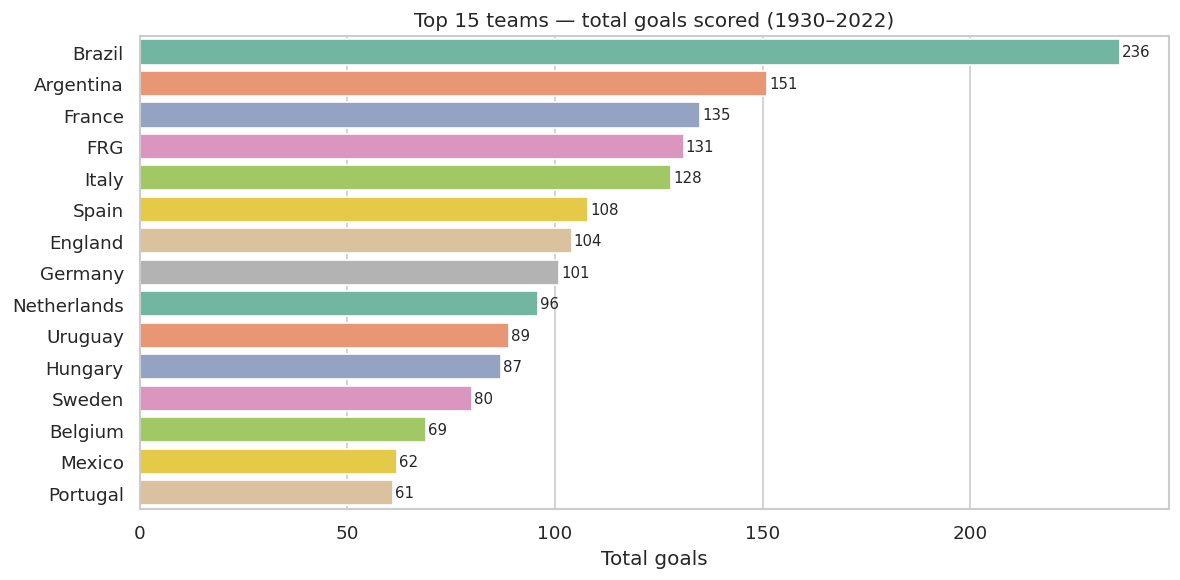

In [4]:
home_goals = matches.groupby("home_team")["home_result"].sum().rename("goals")
away_goals = matches.groupby("away_team")["away_result"].sum().rename("goals")

top_scorers = (
    pd.concat([home_goals, away_goals])
    .groupby(level=0).sum()
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=top_scorers.values, y=top_scorers.index, ax=ax, palette="Set2")
ax.set(title="Top 15 teams — total goals scored (1930–2022)",
       xlabel="Total goals", ylabel="")
for i, v in enumerate(top_scorers.values):
    ax.text(v + 0.5, i, str(int(v)), va="center", fontsize=9)
plt.tight_layout()
plt.show()


## KPI 3 — Win / Draw / Loss record & win rate — top 10 teams (all editions)

/tmp/ipykernel_1736/678968958.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10["win_rate"], y=top10.index, ax=axes[1], palette="Blues_r")


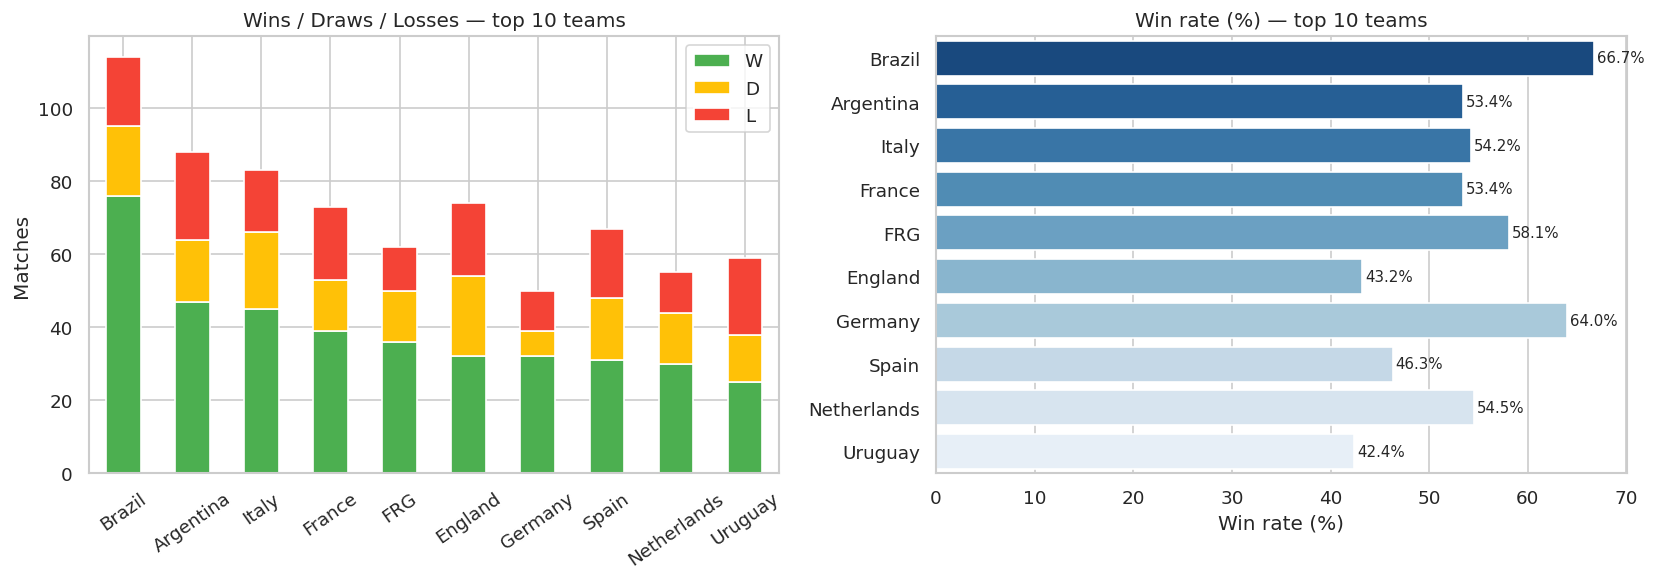

outcome       W   D   L  played  win_rate
team                                     
Brazil       76  19  19     114      66.7
Argentina    47  17  24      88      53.4
Italy        45  21  17      83      54.2
France       39  14  20      73      53.4
FRG          36  14  12      62      58.1
England      32  22  20      74      43.2
Germany      32   7  11      50      64.0
Spain        31  17  19      67      46.3
Netherlands  30  14  11      55      54.5
Uruguay      25  13  21      59      42.4


In [5]:
# result column: "home" = home team won, "away" = away team won, "draw"
home_results = matches.assign(
    team=matches["home_team"],
    outcome=matches["result"].map({"home": "W", "away": "L", "draw": "D"})
)[["team", "outcome"]]

away_results = matches.assign(
    team=matches["away_team"],
    outcome=matches["result"].map({"away": "W", "home": "L", "draw": "D"})
)[["team", "outcome"]]

rec = pd.concat([home_results, away_results], ignore_index=True)

kpi_wins = (
    rec.groupby(["team", "outcome"]).size().unstack(fill_value=0)
    .reindex(columns=["W", "D", "L"], fill_value=0)
)
kpi_wins["played"]   = kpi_wins.sum(axis=1)
kpi_wins["win_rate"] = (kpi_wins["W"] / kpi_wins["played"] * 100).round(1)

top10 = kpi_wins.nlargest(10, "W")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top10[["W", "D", "L"]].plot(kind="bar", stacked=True, ax=axes[0],
                             color=["#4CAF50", "#FFC107", "#F44336"],
                             edgecolor="white")
axes[0].set(title="Wins / Draws / Losses — top 10 teams", xlabel="", ylabel="Matches")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(loc="upper right")

sns.barplot(x=top10["win_rate"], y=top10.index, ax=axes[1], palette="Blues_r")
axes[1].set(title="Win rate (%) — top 10 teams", xlabel="Win rate (%)", ylabel="")
for i, v in enumerate(top10["win_rate"]):
    axes[1].text(v + 0.3, i, f"{v}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()
print(top10[["W", "D", "L", "played", "win_rate"]].to_string())


## KPI 4 — Most prolific editions (goals scored & goals per match)

/tmp/ipykernel_1736/4287158298.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="total_goals", y="label", data=top_total, ax=axes[0], palette="rocket")
/tmp/ipykernel_1736/4287158298.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="goals_per_match", y="label", data=top_gpm, ax=axes[1], palette="mako")
/tmp/ipykernel_1736/4287158298.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="goals_per_match", y="label", data=top_gpm, ax=axes[1], palette="mako")


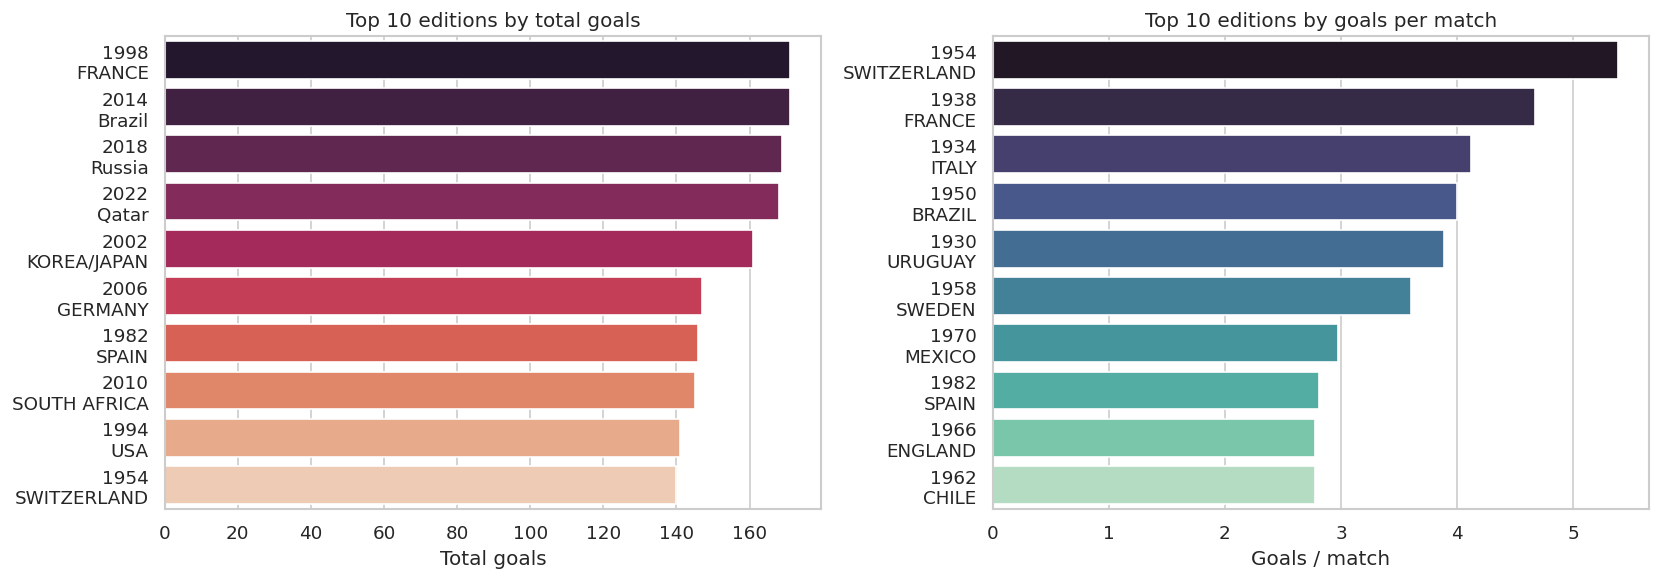

              edition_name  total_goals  n_matches  goals_per_match
edition_year                                                       
1998                FRANCE          171         64             2.67
2014                Brazil          171         64             2.67
2018                Russia          169         64             2.64
2022                 Qatar          168         64             2.62
2002           KOREA/JAPAN          161         64             2.52
2006               GERMANY          147         64             2.30
1982                 SPAIN          146         52             2.81
2010          SOUTH AFRICA          145         64             2.27
1994                   USA          141         52             2.71
1954           SWITZERLAND          140         26             5.38
1986                MEXICO          132         52             2.54
1958                SWEDEN          126         35             3.60
1990                 ITALY          115         

In [6]:
edition_stats = (
    matches.groupby(["edition_year", "edition_name"])["total_goals"]
    .agg(total_goals="sum", n_matches="count")
    .assign(goals_per_match=lambda d: (d["total_goals"] / d["n_matches"]).round(2))
    .reset_index()
    .sort_values("total_goals", ascending=False)
)
edition_stats["label"] = edition_stats["edition_year"].astype(str) + "\n" + edition_stats["edition_name"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_total = edition_stats.nlargest(10, "total_goals")
sns.barplot(x="total_goals", y="label", data=top_total, ax=axes[0], palette="rocket")
axes[0].set(title="Top 10 editions by total goals", xlabel="Total goals", ylabel="")

top_gpm = edition_stats.nlargest(10, "goals_per_match")
sns.barplot(x="goals_per_match", y="label", data=top_gpm, ax=axes[1], palette="mako")
axes[1].set(title="Top 10 editions by goals per match", xlabel="Goals / match", ylabel="")

plt.tight_layout()
plt.show()

print(edition_stats.set_index("edition_year")[["edition_name","total_goals","n_matches","goals_per_match"]].to_string())


## KPI 5 — 2022 World Cup: group stage goals & goal difference per team

/tmp/ipykernel_1736/1147325204.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=goals_by_group.index, y=goals_by_group.values, ax=axes[0], palette="Set2")


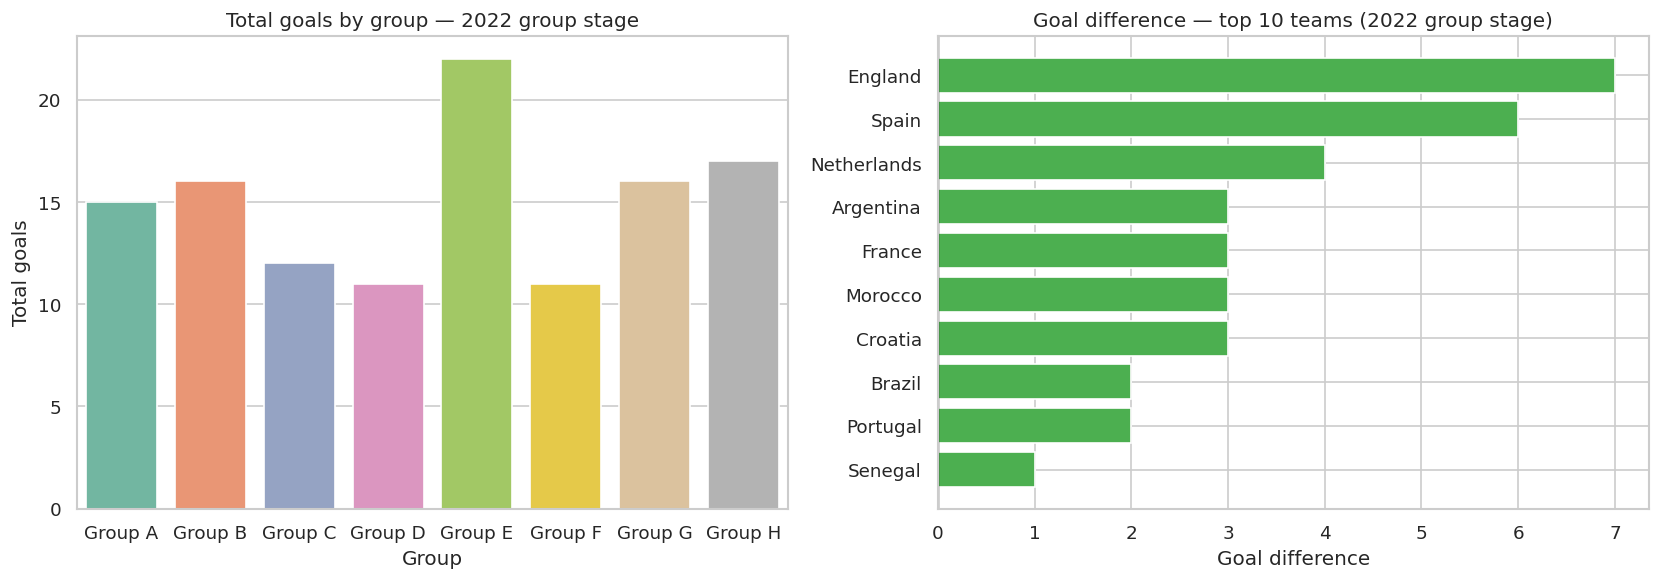

In [7]:
group_stage = matches[
    (matches["edition_year"] == 2022) &
    (matches["round"].str.startswith("Group"))
].copy()

# Goals per group (round column = "Group A", "Group B", …)
goals_by_group = group_stage.groupby("round")["total_goals"].sum().sort_index()

# Goal difference per team
gf = (pd.concat([
    group_stage.groupby("home_team")["home_result"].sum(),
    group_stage.groupby("away_team")["away_result"].sum()
]).groupby(level=0).sum())

ga = (pd.concat([
    group_stage.groupby("home_team")["away_result"].sum(),
    group_stage.groupby("away_team")["home_result"].sum()
]).groupby(level=0).sum())

gd = (gf - ga).sort_values(ascending=False).head(10).rename("goal_diff")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=goals_by_group.index, y=goals_by_group.values, ax=axes[0], palette="Set2")
axes[0].set(title="Total goals by group — 2022 group stage",
            xlabel="Group", ylabel="Total goals")

colors = ["#4CAF50" if v >= 0 else "#F44336" for v in gd.values]
axes[1].barh(gd.index[::-1], gd.values[::-1], color=colors[::-1])
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set(title="Goal difference — top 10 teams (2022 group stage)",
            xlabel="Goal difference", ylabel="")

plt.tight_layout()
plt.show()
